In [4]:
import os
import json
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython import get_ipython

plt.rcParams["font.size"] = "11"
pd.set_option("display.max_rows", 50)


def _find_repo_root(start_dir=None):
    """Walk up directories until the repository root (contains HR/search) is found."""
    here = os.path.abspath(start_dir or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(here, "HR", "search")):
            return here
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    raise FileNotFoundError("Could not locate repository root containing HR/search.")


def _ensure_runtime_state():
    """Load helper notebooks/classes and parameter file if not already loaded."""
    global param

    repo_root = _find_repo_root()
    search_dir = os.path.join(repo_root, "HR", "search")

    if "param" not in globals():
        parser = argparse.ArgumentParser(
            description="Automatic Spectroscopy Search for Exocomet Transits Tutorial",
            epilog="ASSET by RBW",
            allow_abbrev=False,
        )
        parser.add_argument("--p", metavar="param.json", default="param.json", help="parameter file name")
        args, _ = parser.parse_known_args()

        candidate_paths = [
            args.p,
            os.path.join(search_dir, "param.json"),
            os.path.join(repo_root, "param.json"),
        ]
        param_path = next((p for p in candidate_paths if os.path.exists(p)), None)
        if param_path is None:
            raise FileNotFoundError("Could not find param.json for plotting helper.")

        with open(param_path) as paramfile:
            param = json.load(paramfile)

    old_cwd = os.getcwd()
    try:
        os.chdir(search_dir)
        for notebook_name, required_name in [
            ("asset.ipynb", "ASSET"),
            ("otypes.ipynb", "get_otypes"),
            ("reduce_name.ipynb", "to_reduce"),
            ("match_name.ipynb", "find_target"),
        ]:
            if required_name not in globals():
                notebook_path = os.path.join(search_dir, notebook_name)
                if os.path.exists(notebook_path):
                    get_ipython().run_line_magic("run", notebook_path)
    finally:
        os.chdir(old_cwd)

    return param


def _get_save_dir(repo_root):
    save_dir = os.path.join(repo_root, "Images", "starExamples")
    os.makedirs(save_dir, exist_ok=True)
    return save_dir


def plot_single_star_iplotter(star_names, line="K", save_path=None, show=True):
    """Copied from iPlotter workflow: plot one or more stars sequentially."""
    _ensure_runtime_state()
    repo_root = _find_repo_root()

    if isinstance(star_names, str):
        star_names = [star_names]
    else:
        star_names = list(star_names)

    save_dir = _get_save_dir(repo_root)

    def _resolve_target_row(star_name):
        reduced_name = str(star_name)
        if "to_reduce" in globals():
            try:
                reduced_name = to_reduce(str(star_name))
            except Exception:
                pass

        metadata_candidates = [
            "/home/msp25gd/Downloads/res/meta/metadata.pkl",
            os.path.join(repo_root, "res", "meta", "metadata.pkl"),
            os.path.join(repo_root, "metadata.pkl"),
        ]

        metadata_path = next((p for p in metadata_candidates if os.path.exists(p)), None)
        if metadata_path is None:
            raise FileNotFoundError("Could not find metadata.pkl for target resolution.")

        metadata = pd.read_pickle(metadata_path)

        reduced_key = None
        for col in ["Reduced", "reduced"]:
            if col in metadata.columns:
                reduced_key = col
                break

        if reduced_key is None:
            raise KeyError("Metadata does not contain a Reduced column.")

        matches = metadata[metadata[reduced_key].astype(str).str.lower() == reduced_name.lower()]
        if len(matches) == 0:
            raise FileNotFoundError(f"Could not find metadata row for {star_name} ({reduced_name}).")

        return matches.iloc[0]

    for idx, star_name in enumerate(star_names, 1):
        print(f"[{idx}/{len(star_names)}] {star_name}")
        cand_info = _resolve_target_row(star_name)

        star_red = str(cand_info.get("Reduced", cand_info.get("reduced", str(star_name))))
        star_san = str(cand_info.get("Sanitised", cand_info.get("sanitised", star_red)))
        star_harps = cand_info.get("HARPS", cand_info.get("Harps", cand_info.get("HARP", star_red)))

        search = ASSET(parameters=param, line=line)
        search.target_san = star_san
        search.target_red = star_red
        search.target_harps = star_harps

        star_path = os.path.join(param["dataset"], star_red) + "/"
        spec_param = search.spec_analysis(star_path)
        if spec_param is None:
            raise ValueError(f"Not enough spectra for {star_red}.")

        new_spectra, med, med_err = spec_param

        corr_med = med.copy()
        rv_mask = None
        if search.ccf:
            rv_shift = search.X_corr(corr_med)
            rv_mask = (search.radial_velocity > rv_shift - 50) & (search.radial_velocity < rv_shift + 50)
            corr_med[rv_mask] = np.nan

        fig, (ax_flux, ax_snr) = plt.subplots(
            2,
            1,
            figsize=(9, 8),
            sharex=True,
            gridspec_kw={"height_ratios": [2, 1]},
        )

        line_label = f"CaII {line.upper()}" if line.upper() in ["K", "H"] else str(line)
        fig.suptitle(f"{star_san} ({line_label})")

        ax_flux.set_ylabel("Normalised Flux")
        ax_flux.set_xlim(search.rv_min, search.rv_max)

        ax_snr.set_ylabel("SNR ($\\sigma$)")
        ax_snr.set_xlabel("Heliocentric Velocity (km/s)")
        ax_snr.hlines(-1 * search.threshold, search.rv_min, search.rv_max, linestyles="dashed", linewidth=3, colors="red")
        ax_snr.hlines(1 * search.threshold, search.rv_min, search.rv_max, linestyles="dashed", linewidth=3, colors="red")

        for epoch_idx, spec in enumerate(new_spectra):
            snr = search.snr(spec, med, search.spectra_err[epoch_idx], med_err)
            sd = np.std(snr)

            corr_snr = snr.copy()[search.snr_idxrange]
            filtered_rv = search.radial_velocity[search.snr_idxrange]

            if search.ccf and rv_mask is not None:
                corr_snr[rv_mask[search.snr_idxrange]] = np.nan

            sig = corr_snr / sd
            min_detect = float(np.nanmin(sig))

            corr_spec = spec.copy()
            if search.ccf and rv_mask is not None:
                corr_spec[rv_mask] = np.nan

            is_detection = False
            if min_detect < search.threshold:
                width = int(search.get_width(sig)) if np.isfinite(sig).any() else 0
                is_detection = width >= search.width_filter

            if is_detection:
                ax_flux.plot(search.radial_velocity, corr_spec, linewidth=2, alpha=0.7, color="k", zorder=5)
                ax_snr.plot(filtered_rv, sig, linewidth=1.5, color="k", alpha=0.5, zorder=5)
            else:
                ax_flux.plot(search.radial_velocity, corr_spec, linewidth=2, alpha=0.2, color="grey", zorder=0)
                ax_snr.plot(filtered_rv, sig, linewidth=1, color="grey", alpha=0.3, zorder=0)

        ax_flux.plot(search.radial_velocity, corr_med, linewidth=2.5, color="r", label="Median Reference", zorder=10)
        if search.ccf:
            ax_flux.plot(
                search.radial_velocity,
                med,
                linewidth=2.5,
                color="r",
                linestyle="--",
                alpha=0.2,
                label="Original Median Reference",
                zorder=0,
            )

        handles, labels = ax_flux.get_legend_handles_labels()
        handles.extend([
            Line2D([0], [0], label="Superimposed spectra", color="g", alpha=0.2),
            Line2D([0], [0], label="Spectra with detection", color="k"),
        ])
        ax_flux.legend(handles=handles, loc="upper right", fontsize=9)

        out_path = save_path
        if out_path is None:
            safe_name = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in str(star_san))
            out_path = os.path.join(save_dir, f"{safe_name}_{line.upper()}.png")

        fig.savefig(out_path, bbox_inches="tight", dpi=150)
        print(f"Saved figure to {out_path}")

        if show:
            plt.show()
        plt.close(fig)

[1/1] 64psc
Saved figure to /home/msp25gd/ResearchProjectMSc/Images/starExamples/64_Psc_K.png


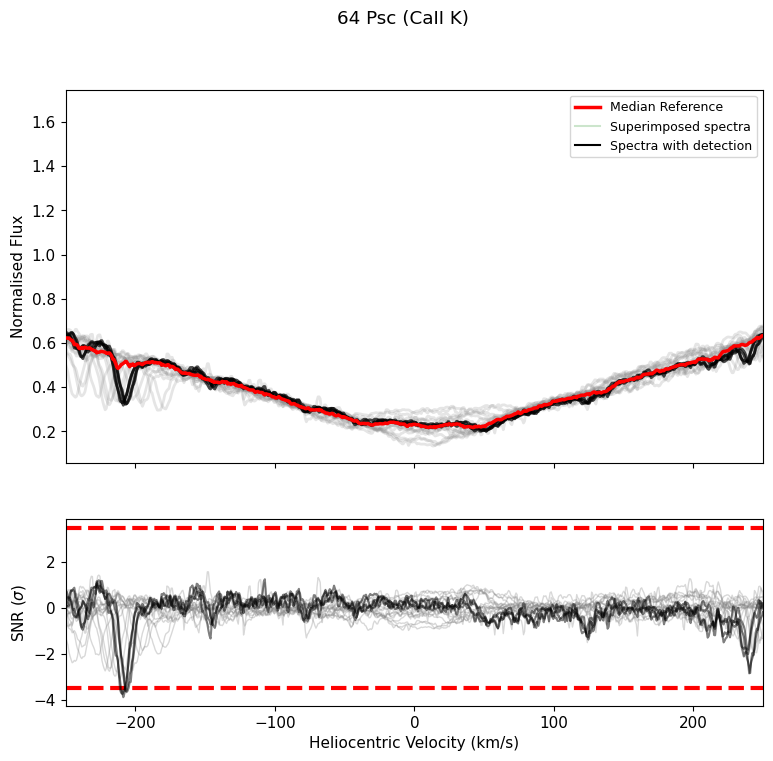

In [5]:
# Input one star as a string, or multiple stars as a list.
# Examples:
# stars_to_plot = "58 aquilae"
# stars_to_plot = ["58 aquilae", "64 psc", "betpic"]
stars_to_plot = "64psc"

# Choose line="K" or line="H"
plot_single_star_iplotter(stars_to_plot, line="K", save_path=None, show=True)

In [27]:
def summarize_star_spectra(star_name, line="K", print_summary=True):
    """
    Summarize spectra coverage for a star and flag detection epochs.

    Returns
    -------
    per_epoch : pd.DataFrame
        One row per spectrum/epoch with night and detection flag.
    by_night : pd.DataFrame
        Night-level summary with counts and number of detections.
    detections_only : pd.DataFrame
        Only detected spectra, with dip-duration information in hours.
    """
    _ensure_runtime_state()
    repo_root = _find_repo_root()

    def _resolve_target_row(local_star_name):
        reduced_name = str(local_star_name)
        if "to_reduce" in globals():
            try:
                reduced_name = to_reduce(str(local_star_name))
            except Exception:
                pass

        metadata_candidates = [
            "/home/msp25gd/Downloads/res/meta/metadata.pkl",
            os.path.join(repo_root, "res", "meta", "metadata.pkl"),
            os.path.join(repo_root, "metadata.pkl"),
        ]
        metadata_path = next((p for p in metadata_candidates if os.path.exists(p)), None)
        if metadata_path is None:
            raise FileNotFoundError("Could not find metadata.pkl for target resolution.")

        metadata = pd.read_pickle(metadata_path)
        reduced_key = "Reduced" if "Reduced" in metadata.columns else "reduced"
        if reduced_key not in metadata.columns:
            raise KeyError("Metadata does not contain a Reduced column.")

        matches = metadata[metadata[reduced_key].astype(str).str.lower() == reduced_name.lower()]
        if len(matches) == 0:
            raise FileNotFoundError(f"Could not find metadata row for {local_star_name} ({reduced_name}).")
        return matches.iloc[0]

    cand_info = _resolve_target_row(star_name)
    star_red = str(cand_info.get("Reduced", cand_info.get("reduced", str(star_name))))
    star_san = str(cand_info.get("Sanitised", cand_info.get("sanitised", star_red)))
    star_harps = cand_info.get("HARPS", cand_info.get("Harps", cand_info.get("HARP", star_red)))

    search = ASSET(parameters=param, line=line)
    search.target_san = star_san
    search.target_red = star_red
    search.target_harps = star_harps

    star_path = os.path.join(param["dataset"], star_red) + "/"
    spec_param = search.spec_analysis(star_path)
    if spec_param is None:
        raise ValueError(f"Not enough spectra for {star_red}.")

    new_spectra, med, med_err = spec_param
    target_info = search.df.copy().reset_index(drop=True)

    # Keep velocity-width duration for reference in the full table.
    filtered_rv_grid = search.radial_velocity[search.snr_idxrange]
    rv_step = float(np.nanmedian(np.abs(np.diff(filtered_rv_grid)))) if len(filtered_rv_grid) > 1 else np.nan

    date_col = "MJD-OBS" if "MJD-OBS" in target_info.columns else ("Date" if "Date" in target_info.columns else None)
    if date_col is not None:
        date_vals = target_info[date_col]
    else:
        date_vals = pd.Series([np.nan] * len(target_info))

    rows = []
    for epoch_idx, spec in enumerate(new_spectra):
        snr = search.snr(spec, med, search.spectra_err[epoch_idx], med_err)
        sd = np.std(snr)
        filtered_rv = search.radial_velocity[search.snr_idxrange]
        sig = snr[search.snr_idxrange] / sd

        min_sigma = float(np.nanmin(sig))
        max_sigma = float(np.nanmax(sig))
        rv_at_min = float(filtered_rv[np.nanargmin(sig)])

        width = 0
        if min_sigma < search.threshold:
            try:
                width = int(search.get_width(sig))
            except Exception:
                width = 0

        dip_duration_kms = float(width * rv_step) if np.isfinite(rv_step) else np.nan
        detected = bool((min_sigma < search.threshold) and (width >= search.width_filter))

        observation_raw = date_vals.iloc[epoch_idx] if epoch_idx < len(date_vals) else np.nan
        obs_num = pd.to_numeric(pd.Series([observation_raw]), errors="coerce").iloc[0]

        if pd.notna(obs_num):
            # MJD to UTC calendar datetime
            obs_dt = pd.to_datetime(float(obs_num), unit="D", origin="1858-11-17", utc=True)
            observation_display = obs_dt.strftime("%Y-%m-%d %H:%M:%S UTC")
            night_label = obs_dt.strftime("%Y-%m-%d")
        else:
            parsed_dt = pd.to_datetime(pd.Series([observation_raw]), errors="coerce", utc=True).iloc[0]
            if pd.notna(parsed_dt):
                observation_display = parsed_dt.strftime("%Y-%m-%d %H:%M:%S UTC")
                night_label = parsed_dt.strftime("%Y-%m-%d")
                obs_num = np.nan
            elif pd.notna(observation_raw):
                observation_display = str(observation_raw)
                night_label = "unknown"
                obs_num = np.nan
            else:
                observation_display = "unknown"
                night_label = "unknown"
                obs_num = np.nan

        rows.append(
            {
                "epoch": epoch_idx + 1,
                "observation": observation_display,
                "observation_mjd": float(obs_num) if pd.notna(obs_num) else np.nan,
                "night": night_label,
                "min_sigma": round(min_sigma, 3),
                "max_sigma": round(max_sigma, 3),
                "rv_at_min": round(rv_at_min, 2),
                "width": width,
                "dip_duration_kms": round(dip_duration_kms, 2) if np.isfinite(dip_duration_kms) else np.nan,
                "detected": detected,
            }
        )

    per_epoch = pd.DataFrame(rows)

    # Estimate dip duration in hours from observation times for contiguous detected events.
    per_epoch["dip_duration_hours"] = np.nan
    ordered = per_epoch.sort_values("observation_mjd").reset_index()

    i = 0
    while i < len(ordered):
        if not bool(ordered.loc[i, "detected"]):
            i += 1
            continue

        start = i
        j = i
        while j + 1 < len(ordered) and bool(ordered.loc[j + 1, "detected"]):
            j += 1

        start_obs = ordered.loc[start, "observation_mjd"]
        end_obs = ordered.loc[j, "observation_mjd"]
        if pd.notna(start_obs) and pd.notna(end_obs):
            span_hours = max(0.0, float(end_obs) - float(start_obs)) * 24.0
            span_hours = round(span_hours, 3)
        else:
            span_hours = np.nan

        original_idxs = ordered.loc[start:j, "index"].to_list()
        per_epoch.loc[original_idxs, "dip_duration_hours"] = span_hours

        i = j + 1

    by_night = (
        per_epoch.groupby("night", dropna=False)
        .agg(
            n_spectra=("epoch", "count"),
            n_detected=("detected", "sum"),
            detected_any=("detected", "max"),
        )
        .reset_index()
        .sort_values("night")
    )

    detections_only = per_epoch[per_epoch["detected"]].copy().reset_index(drop=True)
    detections_only = detections_only[
        ["epoch", "observation", "dip_duration_hours", "night", "rv_at_min", "min_sigma", "width"]
    ]

    if print_summary:
        print(f"Star: {star_san} ({star_red})")
        print(f"Line: {line.upper()}")
        print(f"Total spectra: {len(per_epoch)}")
        print(f"Nights observed: {by_night.shape[0]}")
        print(f"Spectra with detections: {int((per_epoch['detected']).sum())}")
        print("\nPer-night summary:")
        display(by_night)
        print("\nPer-epoch details (detected=True are flagged):")
        display(per_epoch)
        print("\nDetected spectra only (dip duration in hours):")
        display(detections_only)

    return per_epoch, by_night, detections_only


# Example:
# per_epoch_df, by_night_df, detections_df = summarize_star_spectra("64psc", line="K")

In [28]:
# Run summary for a star (single example)
per_epoch_df, by_night_df, detections_df = summarize_star_spectra("64psc", line="K", print_summary=True)

Star: 64 Psc (64psc)
Line: K
Total spectra: 20
Nights observed: 19
Spectra with detections: 4

Per-night summary:


,night,n_spectra,n_detected,detected_any
0,2022-09-05,1,1,True
1,2022-09-18,1,0,False
2,2022-09-20,1,1,True
3,2022-09-21,1,1,True
4,2022-09-23,1,0,False
5,2022-09-24,1,0,False
6,2022-09-25,1,0,False
7,2022-09-29,1,0,False
8,2024-06-09,1,0,False
9,2024-06-19,1,0,False



Per-epoch details (detected=True are flagged):


,epoch,observation,observation_mjd,night,min_sigma,max_sigma,rv_at_min,width,dip_duration_kms,detected,dip_duration_hours
0,1,2022-09-05 09:28:30 UTC,59827.394801,2022-09-05,-3.899,1.247,-208.69,7,5.34,True,0.000
1,2,2022-09-18 07:20:27 UTC,59840.305869,2022-09-18,-2.631,0.774,-218.61,0,0.00,False,NaN
2,3,2022-09-20 05:10:18 UTC,59842.215489,2022-09-20,-3.678,1.155,-206.40,7,5.34,True,24.088
3,4,2022-09-21 05:15:36 UTC,59843.219174,2022-09-21,-3.771,1.202,-209.45,7,5.34,True,24.088
4,5,2022-09-23 03:10:34 UTC,59845.132347,2022-09-23,-2.057,0.518,-226.24,0,0.00,False,NaN
5,6,2022-09-24 03:19:13 UTC,59846.138356,2022-09-24,-2.394,0.623,-245.31,0,0.00,False,NaN
6,7,2022-09-25 03:41:50 UTC,59847.154059,2022-09-25,-1.703,0.638,-238.45,0,0.00,False,NaN
7,8,2022-09-29 03:03:55 UTC,59851.127730,2022-09-29,-2.723,1.146,-201.82,0,0.00,False,NaN
8,9,2024-06-09 09:49:46 UTC,60470.409571,2024-06-09,-2.699,1.128,-207.16,0,0.00,False,NaN
9,10,2024-06-19 09:10:28 UTC,60480.382275,2024-06-19,-2.768,0.616,-218.61,0,0.00,False,NaN



Detected spectra only (dip duration in hours):


,epoch,observation,dip_duration_hours,night,rv_at_min,min_sigma,width
0,1,2022-09-05 09:28:30 UTC,0.000,2022-09-05,-208.69,-3.899,7
1,3,2022-09-20 05:10:18 UTC,24.088,2022-09-20,-206.40,-3.678,7
2,4,2022-09-21 05:15:36 UTC,24.088,2022-09-21,-209.45,-3.771,7
3,19,2024-08-11 04:55:20 UTC,0.000,2024-08-11,-207.16,-3.625,5


In [29]:
# Temporary query cell: spectral types for stars with assessed images
from astroquery.simbad import Simbad
import pandas as pd

assessed_stars = [
    "hd60753", "hd39060", "betpic",
    "aldebaran", "walker67", "bptau", "hd49798", "hd210121", "hd164769",
]

sim = Simbad()
sim.add_votable_fields("sp_type", "main_id")
rows = []
for star in assessed_stars:
    q = sim.query_object(star)
    if q is None or len(q) == 0:
        rows.append({"star": star, "main_id": None, "sp_type": None})
    else:
        df = q.to_pandas()
        rows.append(
            {
                "star": star,
                "main_id": str(df.loc[0, "main_id"]),
                "sp_type": str(df.loc[0, "sp_type"]),
            }
        )

sp_df = pd.DataFrame(rows)
sp_df["sp_lead"] = sp_df["sp_type"].fillna("").str.strip().str[:1].str.upper()
ab_df = sp_df[sp_df["sp_lead"].isin(["A", "B"])].copy()

print("All assessed stars with spectral types:")
display(sp_df[["star", "main_id", "sp_type"]])
print("\nA/B-type subset:")
display(ab_df[["star", "main_id", "sp_type"]])

All assessed stars with spectral types:


,star,main_id,sp_type
0,hd60753,HD 60753,B3IV
1,hd39060,* bet Pic,A6V
2,betpic,NaN,NaN
3,aldebaran,* alf Tau,K5+III
4,walker67,NaN,NaN
5,bptau,NaN,NaN
6,hd49798,HD 49798,sdO6
7,hd210121,HD 210121,B7II
8,hd164769,HD 164769,B2III



A/B-type subset:


,star,main_id,sp_type
0,hd60753,HD 60753,B3IV
1,hd39060,* bet Pic,A6V
7,hd210121,HD 210121,B7II
8,hd164769,HD 164769,B2III


In [30]:
# Bulk A/B spectral-type lookup for all Assessed images
from pathlib import Path
from astroquery.simbad import Simbad
import pandas as pd

assessed_root = Path("/home/msp25gd/ResearchProjectMSc/HR/results/Assessed")
image_paths = sorted(assessed_root.rglob("*.png"))
image_stars = sorted({p.stem.lower() for p in image_paths})

# Build reduced->sanitised mapping to improve SIMBAD name resolution.
metadata_candidates = [
    Path("/home/msp25gd/Downloads/res/meta/metadata.pkl"),
    Path("/home/msp25gd/ResearchProjectMSc/res/meta/metadata.pkl"),
    Path("/home/msp25gd/ResearchProjectMSc/metadata.pkl"),
]
metadata_path = next((p for p in metadata_candidates if p.exists()), None)

name_map = {}
if metadata_path is not None:
    meta = pd.read_pickle(metadata_path)
    reduced_col = "Reduced" if "Reduced" in meta.columns else ("reduced" if "reduced" in meta.columns else None)
    sanitised_col = "Sanitised" if "Sanitised" in meta.columns else ("sanitised" if "sanitised" in meta.columns else None)
    if reduced_col is not None and sanitised_col is not None:
        slim = meta[[reduced_col, sanitised_col]].dropna().drop_duplicates()
        for _, r in slim.iterrows():
            name_map[str(r[reduced_col]).strip().lower()] = str(r[sanitised_col]).strip()

sim = Simbad()
sim.add_votable_fields("sp_type", "main_id")

rows = []
for reduced_name in image_stars:
    query_candidates = []
    if reduced_name in name_map:
        query_candidates.append(name_map[reduced_name])
    query_candidates.append(reduced_name)

    seen = set()
    query_candidates = [q for q in query_candidates if not (q in seen or seen.add(q))]

    result_row = {"image_name": reduced_name, "query_used": None, "main_id": None, "sp_type": None, "resolved": False}
    for q in query_candidates:
        try:
            qtab = sim.query_object(q)
        except Exception:
            qtab = None

        if qtab is not None and len(qtab) > 0:
            qdf = qtab.to_pandas()
            result_row["query_used"] = q
            result_row["main_id"] = str(qdf.loc[0, "main_id"]) if "main_id" in qdf.columns else None
            result_row["sp_type"] = str(qdf.loc[0, "sp_type"]) if "sp_type" in qdf.columns else None
            result_row["resolved"] = True
            break

    rows.append(result_row)

lookup_df = pd.DataFrame(rows)
lookup_df["sp_lead"] = lookup_df["sp_type"].fillna("").str.strip().str[:1].str.upper()
ab_all_df = lookup_df[lookup_df["sp_lead"].isin(["A", "B"])].copy().sort_values(["sp_lead", "image_name"]).reset_index(drop=True)
unresolved_df = lookup_df[~lookup_df["resolved"]].copy().sort_values("image_name").reset_index(drop=True)

print(f"Assessed image stars: {len(image_stars)}")
print(f"Resolved in SIMBAD: {lookup_df['resolved'].sum()}")
print(f"A/B-type stars found: {len(ab_all_df)}")
print(f"Unresolved names: {len(unresolved_df)}")

print("\nA/B-type stars from Assessed images:")
display(ab_all_df[["image_name", "main_id", "sp_type", "query_used"]])

print("\nUnresolved names (for manual alias follow-up):")
display(unresolved_df[["image_name"]])

Assessed image stars: 498
Resolved in SIMBAD: 282
A/B-type stars found: 123
Unresolved names: 216

A/B-type stars from Assessed images:


,image_name,main_id,sp_type,query_used
0,51oph,* c Oph,A0V,51 Oph
1,b001137,HD 5514,A3,b001137
2,betpic,* bet Pic,A6V,bet Pic
3,hd10638,HD 10638,A3,HD 10638
4,hd11753,* phi Phe,A3V,HD 11753
...,...,...,...,...
118,v393sco,V* V393 Sco,B3III,V393Sco
119,v4641sgr,V* V4641 Sgr,B9III,V4641 Sgr
120,vfts779,VFTS 779,B1II-Ib,VFTS 779
121,walker67,LS VI +09 13,B1V,Walker 67



Unresolved names (for manual alias follow-up):


,image_name
0,10223226
1,11193525+09555691
2,154045124004586
3,173554583350564
4,2001nn
...,...
211,wd2200136
212,wd2248504
213,wd2330212
214,x1822371


In [31]:
# Plain text list for quick copy/paste
ab_name_type = ab_all_df[["image_name", "sp_type"]].drop_duplicates().sort_values("image_name").reset_index(drop=True)
print("A/B stars (image_name | sp_type):")
for _, r in ab_name_type.iterrows():
    print(f"{r['image_name']} | {r['sp_type']}")
print(f"\nTotal A/B stars: {len(ab_name_type)}")

A/B stars (image_name | sp_type):
18peg | B3III
28cma | B2.5Ve
51oph | A0V
58aquilae | B9IV
alphavir | B1V
b001137 | A3
betacmi | B8Ve
betpic | A6V
deltasco | B0.3IV
hbc93275 | B5II-Ib
hd101545b | B0.5Iab
hd106068 | B8Ia/ab
hd10638 | A3
hd106391 | B2Ia/ab
hd110432 | B0.5IVpe
hd112272 | B0.5Ia
hd112842 | B4II
hd115842 | B0.5Ia
hd11753 | A3V
hd117880 | B9IV/V
hd119682 | B0Ve
hd120710 | B9IV
hd124195 | B5V
hd125823 | B2V
hd130095 | B9V
hd130437 | B1Ve
hd133518 | B2IVpHe
hd141569 | A2VekB9mB9(_lB)
hd147165 | B1III+B1:V
hd147888 | B3V
hd148184 | B2Vne
hd148379 | B2Iab
hd15130 | A0V
hd152235 | B0.5Ia
hd152478 | B3Vnpe
hd153295 | B2e
hd154873 | B1Ib
hd157038 | B3Iap
hd158681 | B6IV:
hd161056 | B3II/III
hd161103 | B0.5III/IVe
hd162718 | B3/5ne
hd163745 | B5II
hd164769 | B2III
hd167838 | B3Ia/ab
hd169454 | B1Ia+
hd170740 | B2V+
hd175640 | B9IIIpHgMnEu
hd180885 | B6IIIe
hd183143 | B7Ia+
hd184915 | B0.5IIIn
hd210121 | B7II
hd217522 | ApSrSi:
hd225253 | B8IV/V
hd23180 | B1III
hd23642 | A0VpSi+Am
h